## Visualization of Surface Temperature, Salinity, and Dissolved Oxygen in Elkhorn Slough with Reduced Wind 

In this notebook, I will analyze and visualize outputs from the model run on Spartan HPC. I will examine time series comparisons of mean salinity, surface temperature, and surface DO from a control simulation and a 50% reduced wind simulation. I will also show differences between real observations and the simulated results from my model runs.

Lastly, I will create movies of the output from both the control and reduced wind simulations, as well as the difference between the two. 

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import moviepy.video.io.ImageSequenceClip

### Time Series Comparisons

#### Real-World Observations vs. Control Simulated Output

First we will compare real world observations to our modeled output to see how close our simulated results are to reality. I will begin by importing data and setting up file paths. Then I will 

In [4]:
Nx, Ny, Nr = 360, 240, 5

# Define a path to this folder
control_dir = "/Users/rilee/MS 274/Final_Project/results_control_7day"
bathy_file = "slough_bathymetry.bin"

# Model settings
deltaT = 300  # seconds
steps_per_day = int(86400 / deltaT)

# Daily output timesteps for the 7-day run
steps = [288, 576, 864, 1152, 1440, 1728, 2016]

# Model start date from data.cal
model_start_date = pd.Timestamp("2024-01-01")

# Load bathymetry mask
bathy = np.fromfile(bathy_file, dtype=">f4").reshape((Ny, Nx))
mask = bathy < 0

In [5]:
def read_ts(results_dir, step):
    path = os.path.join(
        results_dir,
        "diags",
        "TS",
        f"TS.{step:010d}.data"
    )
    arr = np.fromfile(path, dtype=">f4").reshape((2, Nr, Ny, Nx))
    theta = arr[0]
    salt = arr[1]
    return theta, salt


def read_do(results_dir, step):
    path = os.path.join(
        results_dir,
        "diags",
        "DO",
        f"DO.{step:010d}.data"
    )
    arr = np.fromfile(path, dtype=">f4").reshape((1, Nr, Ny, Nx))
    do = arr[0]
    return do


model_dates = []
model_temp_mean = []
model_salt_mean = []
model_do_mean = []

for step in steps:
    # timestep 288 = end of day 1 = Jan 2 if start is Jan 1 at 00:00
    model_date = model_start_date + pd.to_timedelta(step * deltaT, unit="s")
    model_dates.append(model_date)

    theta, salt = read_ts(control_dir, step)
    do = read_do(control_dir, step)

    theta_surf = theta[0]
    salt_surf = salt[0]
    do_surf = do[0]

    valid = (
        mask
        & (theta_surf > 0)
        & (salt_surf > 0)
        & (do_surf > 0)
    )

    model_temp_mean.append(np.mean(theta_surf[valid]))
    model_salt_mean.append(np.mean(salt_surf[valid]))
    model_do_mean.append(np.mean(do_surf[valid]))

model_df = pd.DataFrame({
    "Date": model_dates,
    "Model_Temp": model_temp_mean,
    "Model_Sal": model_salt_mean,
    "Model_DO": model_do_mean,
}).set_index("Date")

model_df

,Model_Temp,Model_Sal,Model_DO
Date,,,
2024-01-02,16.495945,33.045593,6.654990
2024-01-03,16.488735,33.050720,6.654249
2024-01-04,16.426798,33.059948,6.641770
2024-01-05,16.241175,33.065521,6.633076
2024-01-06,16.135712,33.066605,6.637425
2024-01-07,16.138346,33.066086,6.648169
2024-01-08,16.026775,33.071075,6.649133


In [7]:
# Load observation station data

station_file = "/Users/rilee/MS 274/Final_Project/elkhorn_temp_data/ELKVMWQ.csv"

stations = pd.read_csv(
    station_file,
    parse_dates=["DateTimeStamp"],
    header=2,
    index_col=2,
    dtype={5: str}
)

# Make sure index is datetime
stations.index = pd.to_datetime(stations.index)

# Convert relevant columns to numeric
for col in ["Temp", "DO"]:
    if col in stations.columns:
        stations[col] = pd.to_numeric(stations[col], errors="coerce")

stations.head()

,Station_Code,isSWMP,Historical,ProvisionalPlus,F_Record,Temp,F_Temp,SpCond,F_SpCond,Sal,...,cDepth,F_cDepth,Level,F_Level,cLevel,F_cLevel,pH,F_pH,Turb,F_Turb
DateTimeStamp,,,,,,,,,,,,,,,,,,,,,
2015-10-01 00:00:00,elkvmwq,P,1,1,NaN,15.8,<0>,NaN,<-3> [SPC],NaN,...,NaN,NaN,NaN,<-3> [SCF] (CSM),NaN,<-3> [GCR],7.9,<0>,2.0,<0>
2015-10-01 00:15:00,elkvmwq,P,1,1,NaN,15.9,<0>,NaN,<-3> [SPC],NaN,...,NaN,NaN,NaN,<-3> [SCF] (CSM),NaN,<-3> [GCR],7.9,<0>,2.0,<0>
2015-10-01 00:30:00,elkvmwq,P,1,1,NaN,15.9,<0>,NaN,<-3> [SPC],NaN,...,NaN,NaN,NaN,<-3> [SCF] (CSM),NaN,<-3> [GCR],7.9,<0>,1.0,<0>
2015-10-01 00:45:00,elkvmwq,P,1,1,NaN,15.8,<0>,NaN,<-3> [SPC],NaN,...,NaN,NaN,NaN,<-3> [SCF] (CSM),NaN,<-3> [GCR],7.9,<0>,2.0,<0>
2015-10-01 01:00:00,elkvmwq,P,1,1,NaN,15.5,<0>,NaN,<-3> [SPC],NaN,...,NaN,NaN,NaN,<-3> [SCF] (CSM),NaN,<-3> [GCR],7.9,<0>,1.0,<0>


In [9]:
stations.columns
stations = stations.rename(columns={"DO_mgl": "DO"})

In [10]:
# Daily observed means

obs_temp_daily = stations["Temp"].resample("D").mean()

if "DO" in stations.columns:
    obs_do_daily = stations["DO"].resample("D").mean()
else:
    raise ValueError("No DO column found. Check stations.columns for the DO column name.")

obs_df = pd.DataFrame({
    "Obs_Temp": obs_temp_daily,
    "Obs_DO": obs_do_daily,
})

# Keep only the model date range
obs_df_model_window = obs_df.loc[model_df.index.min():model_df.index.max()]

obs_df_model_window

,Obs_Temp,Obs_DO
DateTimeStamp,,
2024-01-02,14.606250,8.339583
2024-01-03,14.377083,8.273958
2024-01-04,14.135417,8.213542
2024-01-05,14.093750,7.920833
2024-01-06,13.872917,8.033333
2024-01-07,13.278125,8.226042
2024-01-08,13.196875,8.114583


In [11]:
comparison_df = model_df.join(obs_df_model_window, how="left")
comparison_df

,Model_Temp,Model_Sal,Model_DO,Obs_Temp,Obs_DO
Date,,,,,
2024-01-02,16.495945,33.045593,6.654990,14.606250,8.339583
2024-01-03,16.488735,33.050720,6.654249,14.377083,8.273958
2024-01-04,16.426798,33.059948,6.641770,14.135417,8.213542
2024-01-05,16.241175,33.065521,6.633076,14.093750,7.920833
2024-01-06,16.135712,33.066605,6.637425,13.872917,8.033333
2024-01-07,16.138346,33.066086,6.648169,13.278125,8.226042
2024-01-08,16.026775,33.071075,6.649133,13.196875,8.114583


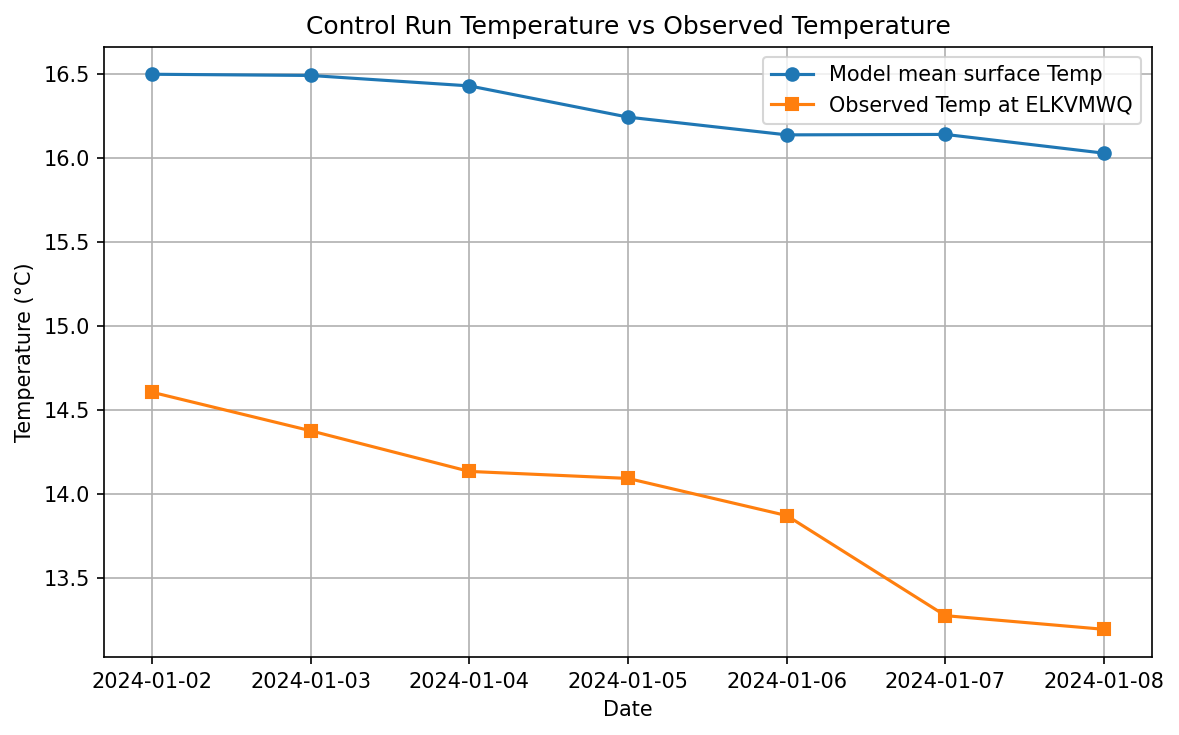

In [12]:
plt.figure(figsize=(8, 5), dpi=150)

plt.plot(
    comparison_df.index,
    comparison_df["Model_Temp"],
    marker="o",
    label="Model mean surface Temp"
)

plt.plot(
    comparison_df.index,
    comparison_df["Obs_Temp"],
    marker="s",
    label="Observed Temp at ELKVMWQ"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Control Run Temperature vs Observed Temperature")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("control_temperature_vs_observations.png", dpi=300, bbox_inches="tight")
plt.show()

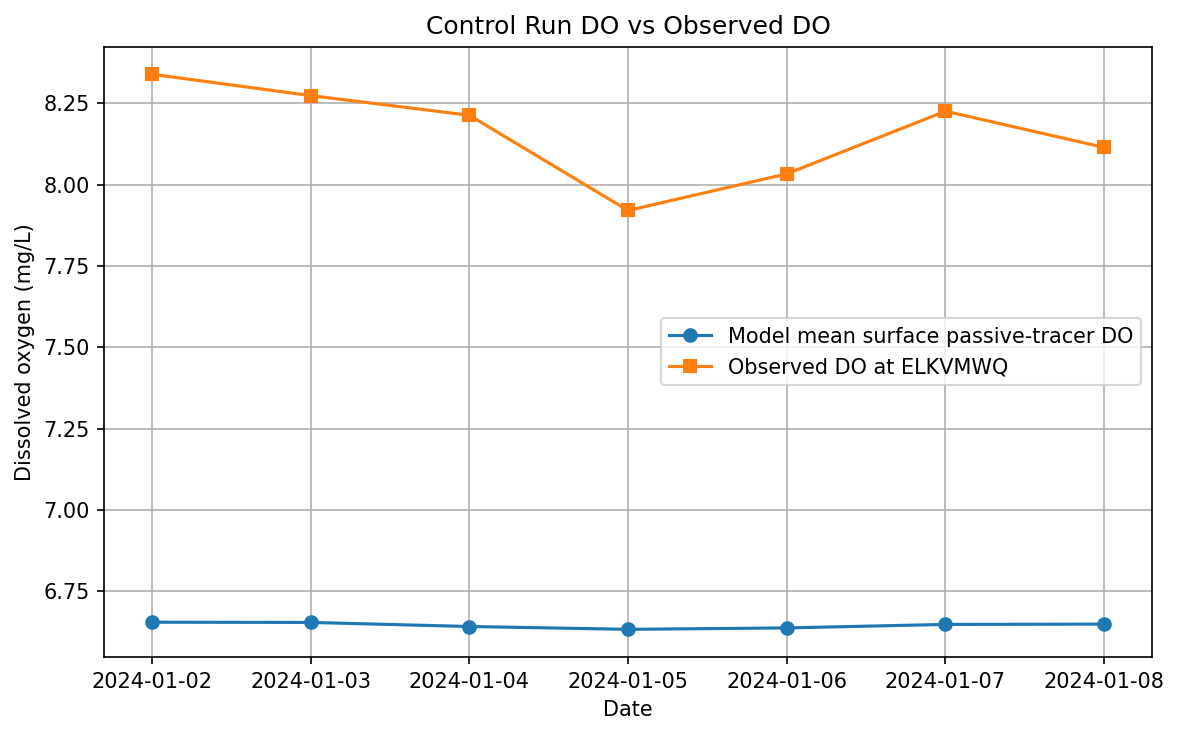

In [13]:
plt.figure(figsize=(8, 5), dpi=150)

plt.plot(
    comparison_df.index,
    comparison_df["Model_DO"],
    marker="o",
    label="Model mean surface passive-tracer DO"
)

plt.plot(
    comparison_df.index,
    comparison_df["Obs_DO"],
    marker="s",
    label="Observed DO at ELKVMWQ"
)

plt.xlabel("Date")
plt.ylabel("Dissolved oxygen (mg/L)")
plt.title("Control Run DO vs Observed DO")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("control_DO_vs_observations.png", dpi=300, bbox_inches="tight")
plt.show()

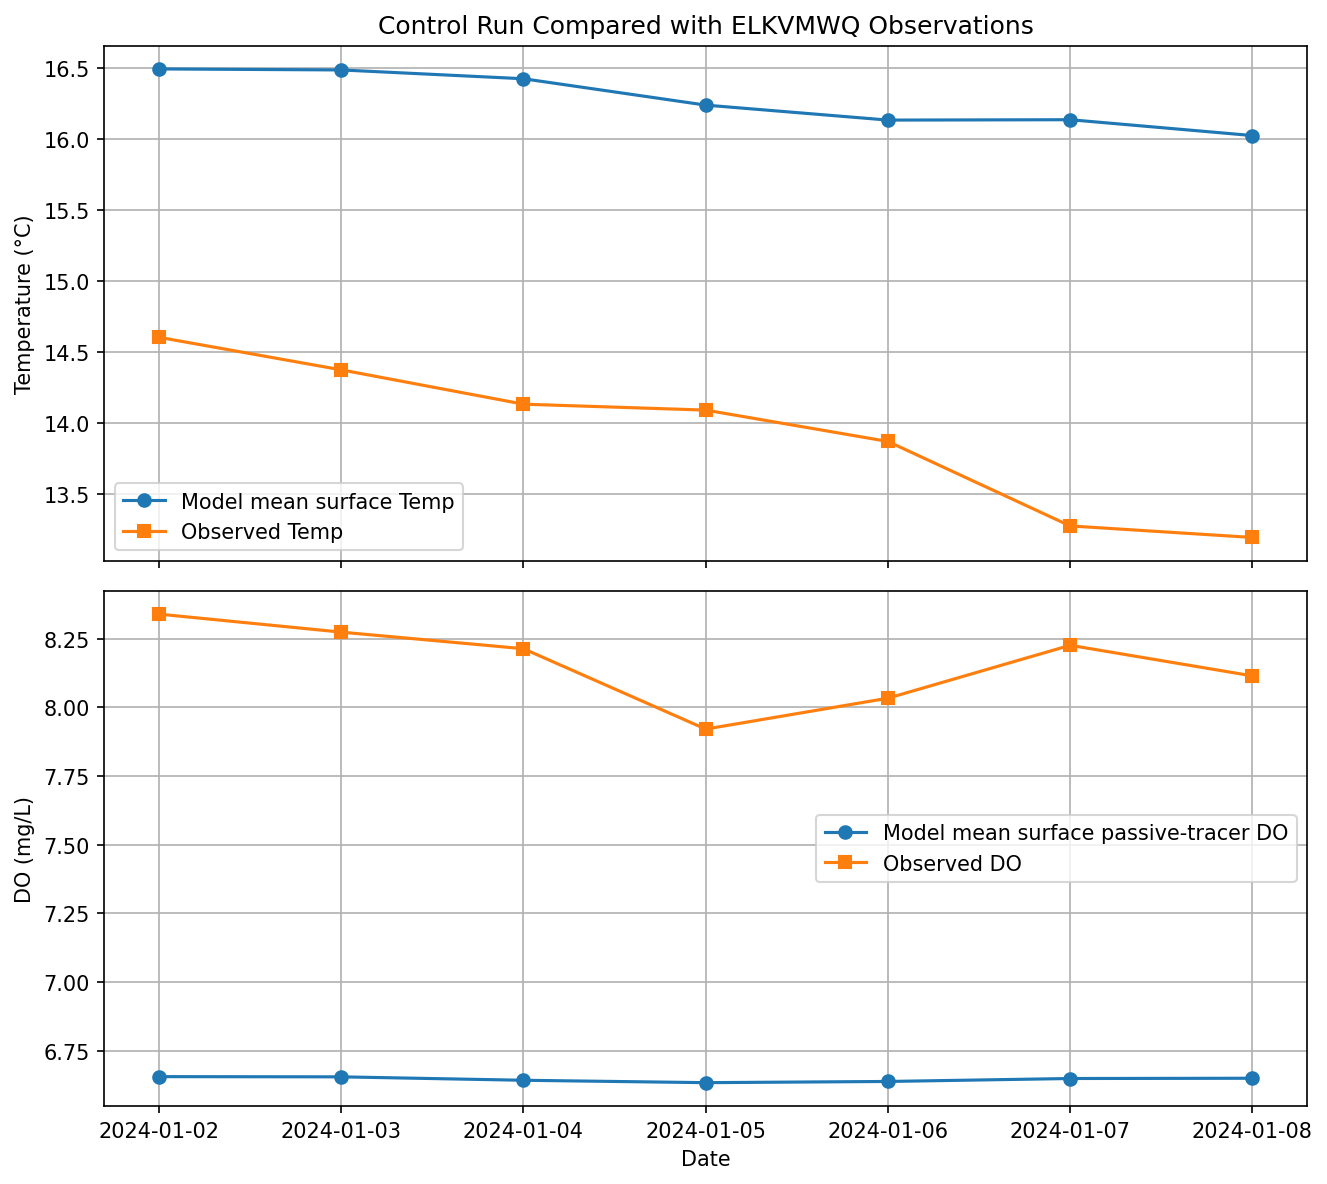

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8), dpi=150, sharex=True)

axes[0].plot(
    comparison_df.index,
    comparison_df["Model_Temp"],
    marker="o",
    label="Model mean surface Temp"
)
axes[0].plot(
    comparison_df.index,
    comparison_df["Obs_Temp"],
    marker="s",
    label="Observed Temp"
)
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Control Run Compared with ELKVMWQ Observations")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(
    comparison_df.index,
    comparison_df["Model_DO"],
    marker="o",
    label="Model mean surface passive-tracer DO"
)
axes[1].plot(
    comparison_df.index,
    comparison_df["Obs_DO"],
    marker="s",
    label="Observed DO"
)
axes[1].set_ylabel("DO (mg/L)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("control_temp_DO_vs_observations.png", dpi=300, bbox_inches="tight")
plt.show()

I compared the control simulation against daily mean observations from the ELKVMWQ station. The model values represent spatially averaged surface conditions over all valid wet cells, while the observations represent a single station, so the comparison is not expected to match exactly. The comparison is used as a general sanity check of the model’s temperature and dissolved oxygen ranges over the 7-day control simulation. Model DO was implemented as a passive tracer, so differences from observed DO are expected because the model does not include oxygen production, respiration, sediment oxygen demand, or air-sea gas exchange.

#### Control Model Run vs. Reduced Wind Model Run Timeseries

Now I will plot timeseries of both the control run simualtion and the 50% reduced wind simulation to compare model outputs.

In [17]:
reduced_dir = "/Users/rilee/MS 274/Final_Project/results_reduced_wind_7day"
# Daily output timesteps for 7-day run
# deltaT = 300 s, daily frequency = 86400 s = 288 steps
steps = [288, 576, 864, 1152, 1440, 1728, 2016]

# Load bathymetry/mask
bathy = np.fromfile(bathy_file, dtype=">f4").reshape((Ny, Nx))
mask = bathy < 0


In [18]:
def read_ts(results_dir, step):
    """
    Read THETA and SALT diagnostic file.

    TS file shape:
    (2, Nr, Ny, Nx)
    index 0 = THETA
    index 1 = SALT
    """
    path = os.path.join(
        results_dir,
        "diags",
        "TS",
        f"TS.{step:010d}.data"
    )

    arr = np.fromfile(path, dtype=">f4").reshape((2, Nr, Ny, Nx))

    theta = arr[0]
    salt = arr[1]

    return theta, salt


def read_do(results_dir, step):
    """
    Read passive tracer DO diagnostic file.

    DO file shape:
    (1, Nr, Ny, Nx)
    index 0 = DO tracer
    """
    path = os.path.join(
        results_dir,
        "diags",
        "DO",
        f"DO.{step:010d}.data"
    )

    arr = np.fromfile(path, dtype=">f4").reshape((1, Nr, Ny, Nx))

    do = arr[0]

    return do

In [19]:
control_theta_mean = []
reduced_theta_mean = []

control_salt_mean = []
reduced_salt_mean = []

control_do_mean = []
reduced_do_mean = []

days = []

for step in steps:
    day = step / 288
    days.append(day)

    ctrl_theta, ctrl_salt = read_ts(control_dir, step)
    red_theta, red_salt = read_ts(reduced_dir, step)

    ctrl_do = read_do(control_dir, step)
    red_do = read_do(reduced_dir, step)

    # Surface layer
    ctrl_theta_surf = ctrl_theta[0]
    red_theta_surf = red_theta[0]

    ctrl_salt_surf = ctrl_salt[0]
    red_salt_surf = red_salt[0]

    ctrl_do_surf = ctrl_do[0]
    red_do_surf = red_do[0]

    # Valid cells: wet bathymetry and positive tracer values
    valid = (
        mask
        & (ctrl_theta_surf > 0)
        & (red_theta_surf > 0)
        & (ctrl_salt_surf > 0)
        & (red_salt_surf > 0)
        & (ctrl_do_surf > 0)
        & (red_do_surf > 0)
    )

    control_theta_mean.append(np.mean(ctrl_theta_surf[valid]))
    reduced_theta_mean.append(np.mean(red_theta_surf[valid]))

    control_salt_mean.append(np.mean(ctrl_salt_surf[valid]))
    reduced_salt_mean.append(np.mean(red_salt_surf[valid]))

    control_do_mean.append(np.mean(ctrl_do_surf[valid]))
    reduced_do_mean.append(np.mean(red_do_surf[valid]))

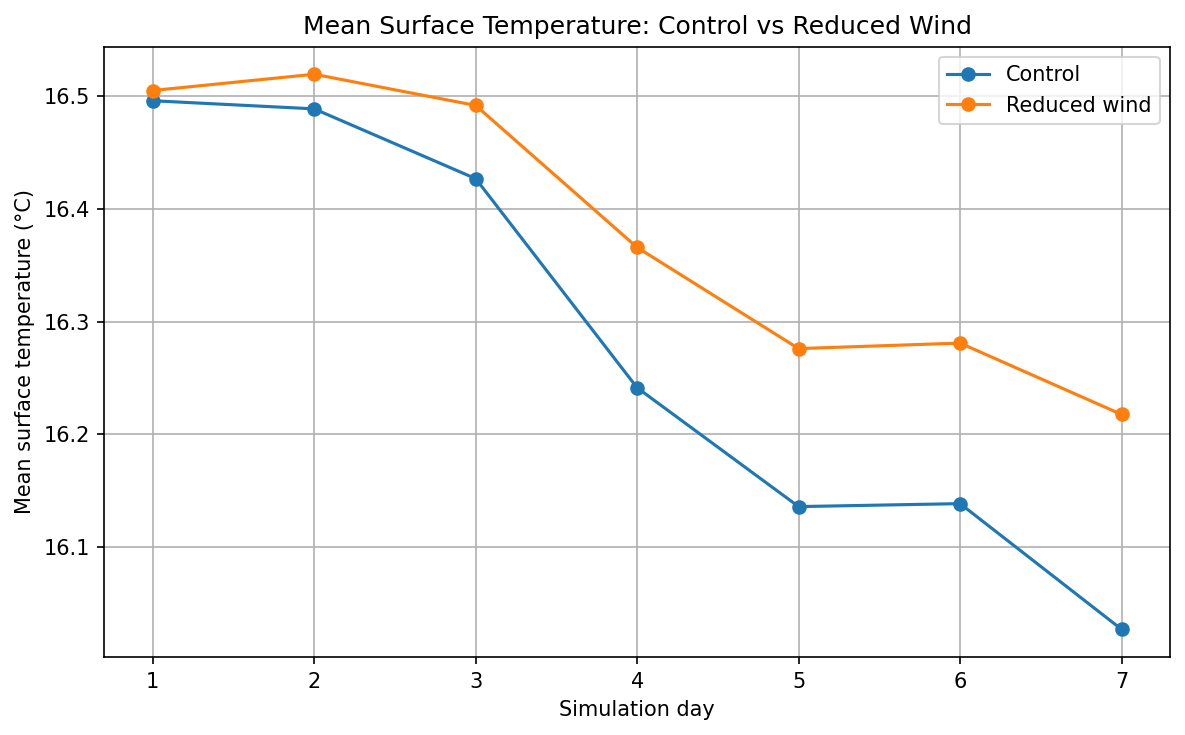

In [20]:
plt.figure(figsize=(8, 5), dpi=150)

plt.plot(days, control_theta_mean, marker="o", label="Control")
plt.plot(days, reduced_theta_mean, marker="o", label="Reduced wind")

plt.xlabel("Simulation day")
plt.ylabel("Mean surface temperature (°C)")
plt.title("Mean Surface Temperature: Control vs Reduced Wind")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("timeseries_surface_temperature.png", dpi=300, bbox_inches="tight")
plt.show()

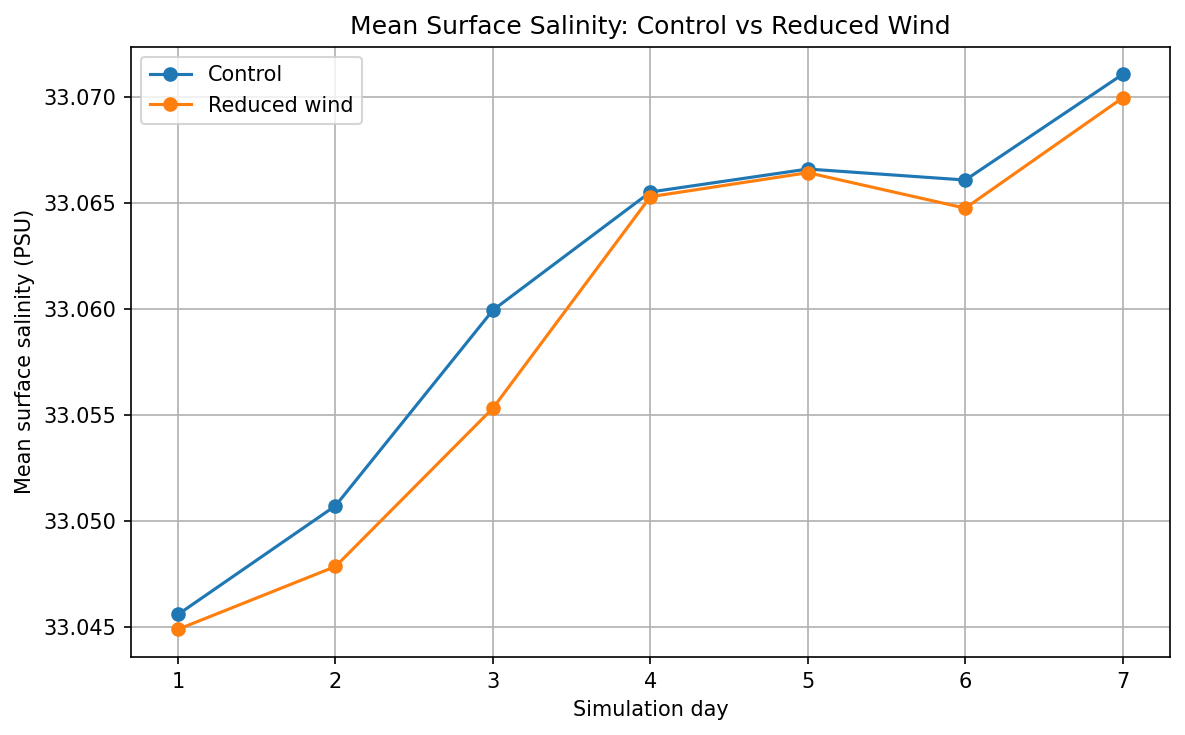

In [21]:
plt.figure(figsize=(8, 5), dpi=150)

plt.plot(days, control_salt_mean, marker="o", label="Control")
plt.plot(days, reduced_salt_mean, marker="o", label="Reduced wind")

plt.xlabel("Simulation day")
plt.ylabel("Mean surface salinity (PSU)")
plt.title("Mean Surface Salinity: Control vs Reduced Wind")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("timeseries_surface_salinity.png", dpi=300, bbox_inches="tight")
plt.show()

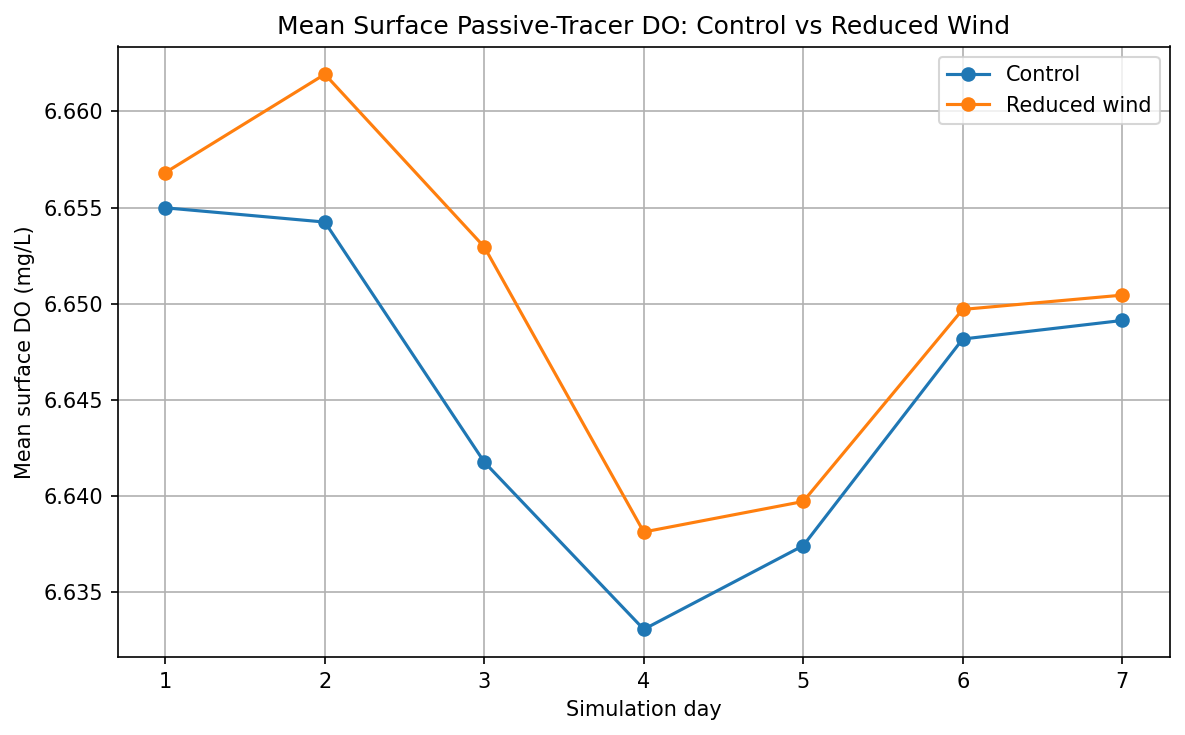

In [22]:
plt.figure(figsize=(8, 5), dpi=150)

plt.plot(days, control_do_mean, marker="o", label="Control")
plt.plot(days, reduced_do_mean, marker="o", label="Reduced wind")

plt.xlabel("Simulation day")
plt.ylabel("Mean surface DO (mg/L)")
plt.title("Mean Surface Passive-Tracer DO: Control vs Reduced Wind")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("timeseries_surface_DO.png", dpi=300, bbox_inches="tight")
plt.show()

### Movies of Model Runs (Control and Reduced Wind Simulations)

In [24]:
os.makedirs("plots/temperature_difference", exist_ok=True)
os.makedirs("plots/DO_difference", exist_ok=True)
os.makedirs("plots/salinity_difference", exist_ok=True)

In [25]:
def plot_temperature_difference_frame(step, image_path):
    ctrl_theta, _ = read_ts(control_dir, step)
    red_theta, _ = read_ts(reduced_dir, step)

    diff = red_theta[0] - ctrl_theta[0]
    diff_plot = np.ma.masked_where(~mask, diff)

    day = step / 288

    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

    cmap = plt.get_cmap("seismic").copy()
    cmap.set_bad("white")

    pcm = ax.pcolormesh(
        diff_plot,
        cmap=cmap,
        vmin=-0.5,
        vmax=0.5,
        shading="auto"
    )

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
    cbar.set_label("Reduced - Control temperature (°C)")

    ax.set_xlabel("Model columns")
    ax.set_ylabel("Model rows")
    ax.set_title(f"Surface Temperature Difference, Day {day:.0f}")

    plt.tight_layout()
    plt.savefig(image_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

In [26]:
file_list = []

for step in steps:
    image_path = os.path.join(
        "plots",
        "temperature_difference",
        f"temperature_difference_{step:010d}.png"
    )

    plot_temperature_difference_frame(step, image_path)
    file_list.append(image_path)

fps = 1

clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(file_list, fps=fps)
clip.write_videofile("temperature_difference_reduced_minus_control.mp4")

Moviepy - Building video temperature_difference_reduced_minus_control.mp4.
Moviepy - Writing video temperature_difference_reduced_minus_control.mp4



Moviepy - Done !
Moviepy - video ready temperature_difference_reduced_minus_control.mp4


In [27]:
def plot_DO_difference_frame(step, image_path):
    ctrl_do = read_do(control_dir, step)
    red_do = read_do(reduced_dir, step)

    diff = red_do[0] - ctrl_do[0]
    diff_plot = np.ma.masked_where(~mask, diff)

    day = step / 288

    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

    cmap = plt.get_cmap("seismic").copy()
    cmap.set_bad("white")

    pcm = ax.pcolormesh(
        diff_plot,
        cmap=cmap,
        vmin=-0.05,
        vmax=0.05,
        shading="auto"
    )

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
    cbar.set_label("Reduced - Control DO (mg/L)")

    ax.set_xlabel("Model columns")
    ax.set_ylabel("Model rows")
    ax.set_title(f"Passive-Tracer DO Difference, Day {day:.0f}")

    plt.tight_layout()
    plt.savefig(image_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

In [28]:
file_list = []

for step in steps:
    image_path = os.path.join(
        "plots",
        "DO_difference",
        f"DO_difference_{step:010d}.png"
    )

    plot_DO_difference_frame(step, image_path)
    file_list.append(image_path)

fps = 1

clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(file_list, fps=fps)
clip.write_videofile("DO_difference_reduced_minus_control.mp4")

Moviepy - Building video DO_difference_reduced_minus_control.mp4.
Moviepy - Writing video DO_difference_reduced_minus_control.mp4



Moviepy - Done !
Moviepy - video ready DO_difference_reduced_minus_control.mp4


In [29]:
def plot_salinity_difference_frame(step, image_path):
    _, ctrl_salt = read_ts(control_dir, step)
    _, red_salt = read_ts(reduced_dir, step)

    diff = red_salt[0] - ctrl_salt[0]
    diff_plot = np.ma.masked_where(~mask, diff)

    day = step / 288

    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

    cmap = plt.get_cmap("seismic").copy()
    cmap.set_bad("white")

    pcm = ax.pcolormesh(
        diff_plot,
        cmap=cmap,
        vmin=-0.05,
        vmax=0.05,
        shading="auto"
    )

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
    cbar.set_label("Reduced - Control salinity (PSU)")

    ax.set_xlabel("Model columns")
    ax.set_ylabel("Model rows")
    ax.set_title(f"Surface Salinity Difference, Day {day:.0f}")

    plt.tight_layout()
    plt.savefig(image_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

In [30]:
file_list = []

for step in steps:
    image_path = os.path.join(
        "plots",
        "salinity_difference",
        f"salinity_difference_{step:010d}.png"
    )

    plot_salinity_difference_frame(step, image_path)
    file_list.append(image_path)

fps = 1

clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(file_list, fps=fps)
clip.write_videofile("salinity_difference_reduced_minus_control.mp4")

Moviepy - Building video salinity_difference_reduced_minus_control.mp4.
Moviepy - Writing video salinity_difference_reduced_minus_control.mp4



Moviepy - Done !
Moviepy - video ready salinity_difference_reduced_minus_control.mp4


Over the 7-day experiment, reducing wind forcing by 50% produced a clear warming response in the model surface waters. By day 7, the reduced-wind run was approximately 0.19 °C warmer on average than the control run. Salinity changed very little between the two runs, suggesting that the short-term wind reduction primarily affected heat/mixing rather than salt distribution in this closed-domain configuration. Passive-tracer dissolved oxygen also showed only small differences, which is expected because the model does not include biological oxygen demand, photosynthesis, air-sea gas exchange, or temperature-dependent oxygen solubility. These results suggest that reduced wind can warm Elkhorn Slough surface waters over short timescales, and that a more complete oxygen model would be needed to evaluate biological DO stress directly.